# TrustCV leakage-checker injection and decision-boundary validation

**Purpose.** This notebook creates the direct evidence requested for Reviewer 3, Major 5. It tests three detector scenarios separately from the grouped AUC-inflation benchmark:

1. patient identifier overlap;
2. exact duplicate feature rows;
3. temporal order violation and temporal-window overlap.

The notebook also checks the exact-duplicate implementation, applies a local index-independent hashing correction when needed, runs controlled injection sweeps, verifies uncontaminated controls across 100 random seeds, saves machine-readable results, and creates an optional supplementary figure.

The experiment is a **software rule-boundary check**. It does not estimate clinical sensitivity, specificity, or a population false-positive rate.

## 1. Imports and paths

Place this notebook either inside the TrustCV repository or beside `trustcv-main.zip`. The setup cell finds an existing repository first. If it cannot find one, it extracts the ZIP into a temporary working folder. The original ZIP is not changed.

In [2]:
import subprocess
import sys

INSTALL_SOURCE = "github" #"pypi"  # "pypi", "github", or "none"


def pip_install(*packages):
    cmd = [sys.executable, "-m", "pip", "install", "-q", *packages]
    print("Running:", " ".join(cmd))
    subprocess.check_call(cmd)

if INSTALL_SOURCE == "pypi":
    pip_install("trustcv>=1.0.7", "scikit-learn>=1.3,<1.8", "pandas", "matplotlib", "tabulate")
elif INSTALL_SOURCE == "github":
    pip_install("git+https://github.com/ki-smile/trustcv.git", "scikit-learn>=1.3,<1.8", "pandas", "matplotlib", "tabulate")
elif INSTALL_SOURCE == "none":
    print("Skipping installation. Make sure trustcv is already importable.")
else:
    raise ValueError("INSTALL_SOURCE must be 'pypi', 'github', or 'none'.")

import trustcv
print("trustcv version:", getattr(trustcv, "__version__", "unknown"))

Running: /usr/bin/python3 -m pip install -q git+https://github.com/ki-smile/trustcv.git scikit-learn>=1.3,<1.8 pandas matplotlib tabulate
trustcv version: 1.0.7


In [5]:
import os

# Clone the trustcv repository so that find_repo_root() can find the source files
# even though the package is already pip installed.
repo_path = 'trustcv-main'
if not os.path.exists(repo_path):
    print(f"Cloning trustcv repository into {repo_path}...")
    !git clone https://github.com/ki-smile/trustcv.git $repo_path
else:
    print(f"Repository already exists at {repo_path}. Skipping clone.")

Repository already exists at trustcv-main. Skipping clone.


In [8]:
!ls -R trustcv-main

trustcv-main:
AUTHORS.md		   fda_validation_report.json	scripts
CHANGELOG.md		   LICENSE			SETUP_INSTRUCTIONS.md
CODE_OF_CONDUCT.md	   MANIFEST.in			setup.py
CONTRIBUTING.md		   notebooks			test_all.py
CV_VERIFICATION_REPORT.md  PROJECT_STATUS.md		test_build.py
DEPLOYMENT_CHECKLIST.md    pyproject.toml		tests
deploy.sh		   README.md			trustcv
docs			   requirements-dev.txt		trustcv_dashboard.html
environment.yml		   requirements-frameworks.txt	website
examples		   requirements.txt

trustcv-main/docs:
 API_REFERENCE.md
 BEST_PRACTICES.md
 conf.py
 CV_METHODS_CHECKLIST.md
 CV_METHODS_TOOLKIT_TABLE.md
 CV_SELECTION_GUIDE.md
 DATA_LEAKAGE_DETECTION.md
 FRAMEWORK_GUIDE.md
 iid_splitters.md
 index.rst
 LEAKAGE_DETECTION_IMPLEMENTATION.md
 ML_TOOLBOX_CV_COMPARISON.md
 PRACTICAL_CV_GUIDE.md
'Quickstart_ IID Cross-Validation with TrustCV.md'
 README.md
 REGULATORY_CV_GUIDELINES.md

trustcv-main/examples:
all_cv_methods_demo.py		 keras_skwrap_digits.py
data_leakage_detection_demo.py	 keras_skwra

In [9]:
from __future__ import annotations

import importlib
import inspect
import json
import shutil
import sys
import warnings
import zipfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

SEED = 42
N_TRAIN = 200
N_TEST = 100
CONTROL_SEEDS = range(100)
OUTPUT_DIR = Path.cwd() / "trustcv_leakage_injection_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def find_repo_root() -> Path:
    candidates = [
        Path.cwd(),
        Path.cwd() / "trustcv-main",
        Path("/mnt/data/trustcv-main"),
    ]
    for p in candidates:
        if (p / "trustcv" / "checkers" / "leakage.py").exists():
            return p.resolve()

    zip_candidates = [
        Path.cwd() / "trustcv-main.zip",
        Path("/mnt/data/trustcv-main.zip"),
    ]
    for zpath in zip_candidates:
        if zpath.exists():
            extract_dir = Path.cwd() / "_trustcv_extracted"
            if not extract_dir.exists():
                with zipfile.ZipFile(zpath) as zf:
                    zf.extractall(extract_dir)
            roots = list(extract_dir.glob("*/trustcv/checkers/leakage.py"))
            if roots:
                return roots[0].parents[2].resolve()

    raise FileNotFoundError(
        "Could not find trustcv/checkers/leakage.py or trustcv-main.zip. "
        "Place the notebook inside the repository or beside the ZIP file."
    )


REPO_ROOT = find_repo_root()
LEAKAGE_FILE = REPO_ROOT / "trustcv" / "checkers" / "leakage.py"
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

print(f"Repository: {REPO_ROOT}")
print(f"Leakage checker: {LEAKAGE_FILE}")
print(f"Outputs: {OUTPUT_DIR}")

Repository: /content/trustcv-main
Leakage checker: /content/trustcv-main/trustcv/checkers/leakage.py
Outputs: /content/trustcv_leakage_injection_outputs


## 2. Inspect and, when required, correct exact-duplicate hashing

The original implementation may call `hash_pandas_object` with its default `index=True`. In that form, two feature-identical rows can receive different hashes when their DataFrame row indices differ. The correction below:

- hashes feature values with `index=False`;
- counts duplicated **test rows**, not only unique shared hashes;
- preserves the same returned dictionary fields.

A backup named `leakage.py.pre_duplicate_fix.bak` is created before the first local modification. Review and commit the resulting source change through the normal repository workflow after the notebook has passed.

In [10]:
source_before = LEAKAGE_FILE.read_text(encoding="utf-8")
needs_patch = (
    "train_hashes = pd.util.hash_pandas_object(X_train)" in source_before
    and "test_hashes = pd.util.hash_pandas_object(X_test)" in source_before
)

if needs_patch:
    old = '''        # Create hash of each row
        train_hashes = pd.util.hash_pandas_object(X_train)
        test_hashes = pd.util.hash_pandas_object(X_test)

        # Find overlaps
        common_hashes = set(train_hashes).intersection(set(test_hashes))

        result: Dict[str, Any] = {
            "has_leakage": len(common_hashes) > 0,
            "duplicate_count": len(common_hashes),
            "duplicate_percentage": (
                len(common_hashes) / len(test_hashes) * 100
            ),
        }
'''
    new = '''        # Hash feature values only. DataFrame indices are bookkeeping
        # metadata and must not determine whether two rows are duplicates.
        train_hashes = pd.util.hash_pandas_object(X_train, index=False)
        test_hashes = pd.util.hash_pandas_object(X_test, index=False)

        # Count duplicated test rows, including repeated copies of the same
        # training row. This is more informative than counting only unique
        # shared hash values.
        train_hash_set = set(train_hashes.to_numpy())
        duplicate_mask = test_hashes.isin(train_hash_set)
        duplicate_count = int(duplicate_mask.sum())

        result: Dict[str, Any] = {
            "has_leakage": duplicate_count > 0,
            "duplicate_count": duplicate_count,
            "duplicate_percentage": (
                duplicate_count / len(test_hashes) * 100
                if len(test_hashes)
                else 0.0
            ),
        }
'''
    if old not in source_before:
        raise RuntimeError(
            "The expected duplicate-check code block was not found. "
            "Inspect leakage.py manually before changing it."
        )
    backup = LEAKAGE_FILE.with_suffix(".py.pre_duplicate_fix.bak")
    if not backup.exists():
        shutil.copy2(LEAKAGE_FILE, backup)
    LEAKAGE_FILE.write_text(source_before.replace(old, new), encoding="utf-8")
    print("Applied index-independent duplicate hashing correction.")
    print(f"Backup: {backup}")
else:
    print("No automatic patch required; the old index-dependent block was not found.")

source_after = LEAKAGE_FILE.read_text(encoding="utf-8")
assert "hash_pandas_object(X_train, index=False)" in source_after
assert "hash_pandas_object(X_test, index=False)" in source_after
print("Verified: duplicate hashing excludes DataFrame indices.")

No automatic patch required; the old index-dependent block was not found.
Verified: duplicate hashing excludes DataFrame indices.


## 3. Import the corrected checker and run focused regression tests

These two tests target the earlier ambiguity directly: a duplicate copied to a different row index must still be detected, and repeated copies must be counted as repeated contaminated test rows.

In [11]:
import importlib.util

spec = importlib.util.spec_from_file_location("trustcv_leakage_local", LEAKAGE_FILE)
if spec is None or spec.loader is None:
    raise ImportError(f"Could not load {LEAKAGE_FILE}")
leakage_module = importlib.util.module_from_spec(spec)
sys.modules[spec.name] = leakage_module
spec.loader.exec_module(leakage_module)
DataLeakageChecker = leakage_module.DataLeakageChecker
checker = DataLeakageChecker(verbose=False)

# A feature-identical row placed at a different DataFrame index.
X_train_test = pd.DataFrame([[1, 2], [3, 4], [5, 6]])
X_test_test = pd.DataFrame([[9, 9], [5, 6]], index=[100, 101])
r1 = checker._check_duplicate_samples(X_train_test, X_test_test)
assert r1["has_leakage"] is True
assert r1["duplicate_count"] == 1

# Two copies of the same training row must count as two contaminated test rows.
X_train_test = pd.DataFrame([[1, 2], [3, 4]])
X_test_test = pd.DataFrame([[3, 4], [3, 4], [8, 9]], index=[10, 20, 30])
r2 = checker._check_duplicate_samples(X_train_test, X_test_test)
assert r2["has_leakage"] is True
assert r2["duplicate_count"] == 2
assert np.isclose(r2["duplicate_percentage"], 200 / 3)

print("PASS: displaced-index exact duplicate detected.")
print("PASS: repeated duplicate rows counted correctly.")
pd.DataFrame([r1, r2], index=["different_index", "repeated_duplicate"])

PASS: displaced-index exact duplicate detected.
PASS: repeated duplicate rows counted correctly.


,has_leakage,duplicate_count,duplicate_percentage
different_index,True,1,50.000000
repeated_duplicate,True,2,66.666667


## 4. Controlled data generator

Each run has 200 training rows and 100 test rows. Clean train and test features are drawn independently from continuous distributions, making accidental exact equality effectively absent. Patient identifiers and timestamps are built to be disjoint and forward ordered in the uncontaminated controls.

In [12]:
def make_clean_split(seed: int, n_features: int = 8) -> dict:
    rng = np.random.default_rng(seed)
    X_train = pd.DataFrame(
        rng.normal(size=(N_TRAIN, n_features)),
        columns=[f"x{j}" for j in range(n_features)],
        index=np.arange(1000, 1000 + N_TRAIN),
    )
    X_test = pd.DataFrame(
        rng.normal(loc=0.25, size=(N_TEST, n_features)),
        columns=X_train.columns,
        index=np.arange(5000, 5000 + N_TEST),
    )
    patient_train = np.arange(10_000, 10_000 + N_TRAIN)
    patient_test = np.arange(20_000, 20_000 + N_TEST)
    time_train = pd.date_range("2020-01-01", periods=N_TRAIN, freq="h")
    time_test = pd.date_range(time_train.max() + pd.Timedelta(hours=1), periods=N_TEST, freq="h")
    return {
        "X_train": X_train,
        "X_test": X_test,
        "patient_train": patient_train,
        "patient_test": patient_test,
        "time_train": time_train,
        "time_test": time_test,
    }

clean = make_clean_split(SEED)
clean_duplicate = checker._check_duplicate_samples(clean["X_train"], clean["X_test"])
clean_patient = checker._check_patient_leakage(clean["patient_train"], clean["patient_test"])
clean_temporal = checker._check_temporal_leakage(clean["time_train"], clean["time_test"])
assert not clean_duplicate["has_leakage"]
assert not clean_patient["has_leakage"]
assert not clean_temporal["has_leakage"]
print("Baseline clean split passes all three focused audits.")

Baseline clean split passes all three focused audits.


## 5. Patient-overlap injection sweep

`k` test patient identifiers are replaced with identifiers from the training partition. Because the test set has 100 records, `k=1` is a 1% injected test-set base rate. The checker’s reported `overlap_percentage` uses another denominator, the union of unique identifiers, and is retained only as a diagnostic field.

In [13]:
def run_patient_sweep(seed: int = SEED) -> pd.DataFrame:
    base = make_clean_split(seed)
    rows = []
    for k in [0, 1, 2, 5, 10, 25]:
        test_ids = base["patient_test"].copy()
        if k:
            test_ids[:k] = base["patient_train"][:k]
        result = checker._check_patient_leakage(base["patient_train"], test_ids)
        rows.append({
            "scenario": "patient_overlap",
            "seed": seed,
            "injected_count": k,
            "injected_test_base_rate": k / N_TEST,
            "flag": bool(result["has_leakage"]),
            "detected_count": int(result["overlap_count"]),
            "checker_overlap_percentage": float(result["overlap_percentage"]),
        })
    return pd.DataFrame(rows)

patient_results = run_patient_sweep()
assert patient_results.loc[patient_results.injected_count.eq(0), "flag"].item() is False
assert patient_results.loc[patient_results.injected_count.eq(1), "flag"].item() is True
patient_results

,scenario,seed,injected_count,injected_test_base_rate,flag,detected_count,checker_overlap_percentage
0,patient_overlap,42,0,0.00,False,0,0.000000
1,patient_overlap,42,1,0.01,True,1,0.334448
2,patient_overlap,42,2,0.02,True,2,0.671141
3,patient_overlap,42,5,0.05,True,5,1.694915
4,patient_overlap,42,10,0.10,True,10,3.448276
5,patient_overlap,42,25,0.25,True,25,9.090909


## 6. Exact-duplicate injection sweep with deliberately displaced row indices

Training rows are copied into the final `k` positions of the test partition, not into matching positions. The DataFrame indices are also disjoint. A successful flag now demonstrates value-based duplicate detection rather than accidental index matching.

In [14]:
def run_duplicate_sweep(seed: int = SEED) -> pd.DataFrame:
    base = make_clean_split(seed)
    rows = []
    for k in [0, 1, 2, 5, 10, 25]:
        X_test = base["X_test"].copy()
        if k:
            source_positions = np.arange(k)
            target_positions = np.arange(N_TEST - k, N_TEST)
            X_test.iloc[target_positions, :] = base["X_train"].iloc[source_positions, :].to_numpy()
        result = checker._check_duplicate_samples(base["X_train"], X_test)
        rows.append({
            "scenario": "exact_duplicate",
            "seed": seed,
            "injected_count": k,
            "injected_test_base_rate": k / N_TEST,
            "flag": bool(result["has_leakage"]),
            "detected_count": int(result["duplicate_count"]),
            "detected_percentage": float(result["duplicate_percentage"]),
        })
    return pd.DataFrame(rows)

duplicate_results = run_duplicate_sweep()
assert duplicate_results.loc[duplicate_results.injected_count.eq(0), "flag"].item() is False
assert duplicate_results.loc[duplicate_results.injected_count.eq(1), "flag"].item() is True
assert np.array_equal(duplicate_results["detected_count"], duplicate_results["injected_count"])
duplicate_results

,scenario,seed,injected_count,injected_test_base_rate,flag,detected_count,detected_percentage
0,exact_duplicate,42,0,0.00,False,0,0.0
1,exact_duplicate,42,1,0.01,True,1,1.0
2,exact_duplicate,42,2,0.02,True,2,2.0
3,exact_duplicate,42,5,0.05,True,5,5.0
4,exact_duplicate,42,10,0.10,True,10,10.0
5,exact_duplicate,42,25,0.25,True,25,25.0


## 7. Temporal order-violation sweep

The uncontaminated test period begins after the training period. For contaminated settings, one or more test timestamps are moved to one hour before the training start. The first flagged setting characterizes the discrete order-violation boundary.

In [15]:
def run_temporal_order_sweep(seed: int = SEED) -> pd.DataFrame:
    base = make_clean_split(seed)
    rows = []
    for k in [0, 1, 2, 5, 10, 25]:
        test_time = pd.Series(base["time_test"].copy())
        if k:
            early = pd.date_range(
                pd.Timestamp(base["time_train"].min()) - pd.Timedelta(hours=k),
                periods=k,
                freq="h",
            )
            test_time.iloc[:k] = early
        result = checker._check_temporal_leakage(base["time_train"], test_time)
        rows.append({
            "scenario": "temporal_order",
            "seed": seed,
            "injected_count": k,
            "injected_test_base_rate": k / N_TEST,
            "flag": bool(result["has_leakage"]),
            "test_before_train": bool(result["test_before_train"]),
            "test_before_train_fraction": float(result["test_before_train_fraction"]),
            "overlap_fraction": float(result["overlap_fraction"]),
        })
    return pd.DataFrame(rows)

temporal_order_results = run_temporal_order_sweep()
assert temporal_order_results.loc[temporal_order_results.injected_count.eq(0), "flag"].item() is False
assert temporal_order_results.loc[temporal_order_results.injected_count.eq(1), "flag"].item() is True
temporal_order_results

,scenario,seed,injected_count,injected_test_base_rate,flag,test_before_train,test_before_train_fraction,overlap_fraction
0,temporal_order,42,0,0.00,False,False,0.00,0.0
1,temporal_order,42,1,0.01,True,True,0.01,0.0
2,temporal_order,42,2,0.02,True,True,0.02,0.0
3,temporal_order,42,5,0.05,True,True,0.05,0.0
4,temporal_order,42,10,0.10,True,True,0.10,0.0
5,temporal_order,42,25,0.25,True,True,0.25,0.0


## 8. Temporal-window-overlap boundary sweep

Exactly the requested borderline region is tested: 0.50 of test timestamps inside the training span must pass, while 0.51 must flag under the current implementation’s `overlap_fraction > 0.50` rule. No test timestamp is allowed to precede the training start in this experiment, so the overlap rule is isolated.

In [16]:
def make_temporal_overlap_case(overlap_fraction: float) -> tuple[pd.DatetimeIndex, pd.DatetimeIndex]:
    train_time = pd.date_range("2020-01-01", periods=N_TRAIN, freq="h")
    k = int(round(overlap_fraction * N_TEST))

    # Timestamps inside [min_train, max_train], selected from the latter part
    # so none precedes the training start.
    inside = train_time[-k:] if k > 0 else pd.DatetimeIndex([])
    outside_n = N_TEST - k
    outside = pd.date_range(
        train_time.max() + pd.Timedelta(hours=1),
        periods=outside_n,
        freq="h",
    )
    test_time = inside.append(outside)
    assert len(test_time) == N_TEST
    return train_time, test_time


def run_temporal_overlap_sweep() -> pd.DataFrame:
    rows = []
    for requested in [0.00, 0.25, 0.49, 0.50, 0.51, 0.75, 1.00]:
        train_time, test_time = make_temporal_overlap_case(requested)
        result = checker._check_temporal_leakage(train_time, test_time)
        rows.append({
            "scenario": "temporal_overlap",
            "requested_overlap_fraction": requested,
            "observed_overlap_fraction": float(result["overlap_fraction"]),
            "flag": bool(result["has_leakage"]),
            "test_before_train": bool(result["test_before_train"]),
        })
    return pd.DataFrame(rows)

temporal_overlap_results = run_temporal_overlap_sweep()
assert temporal_overlap_results.loc[
    temporal_overlap_results.requested_overlap_fraction.eq(0.50), "flag"
].item() is False
assert temporal_overlap_results.loc[
    temporal_overlap_results.requested_overlap_fraction.eq(0.51), "flag"
].item() is True
assert not temporal_overlap_results["test_before_train"].any()
temporal_overlap_results

,scenario,requested_overlap_fraction,observed_overlap_fraction,flag,test_before_train
0,temporal_overlap,0.00,0.00,False,False
1,temporal_overlap,0.25,0.25,False,False
2,temporal_overlap,0.49,0.49,False,False
3,temporal_overlap,0.50,0.50,False,False
4,temporal_overlap,0.51,0.51,True,False
5,temporal_overlap,0.75,0.75,True,False
6,temporal_overlap,1.00,1.00,True,False


## 9. Uncontaminated-control verification across 100 random seeds

This supports the narrow statement: **no flags occurred in the uncontaminated control splits tested here**. It does not support a general claim of zero false positives in other datasets.

In [17]:
control_rows = []
for seed in CONTROL_SEEDS:
    base = make_clean_split(seed)
    p = checker._check_patient_leakage(base["patient_train"], base["patient_test"])
    d = checker._check_duplicate_samples(base["X_train"], base["X_test"])
    t = checker._check_temporal_leakage(base["time_train"], base["time_test"])
    control_rows.append({
        "seed": seed,
        "patient_flag": bool(p["has_leakage"]),
        "duplicate_flag": bool(d["has_leakage"]),
        "temporal_flag": bool(t["has_leakage"]),
    })

control_results = pd.DataFrame(control_rows)
control_summary = control_results[["patient_flag", "duplicate_flag", "temporal_flag"]].sum().to_frame("flag_count")
assert control_summary["flag_count"].sum() == 0
print("PASS: no focused-audit flags across 100 uncontaminated control seeds.")
control_summary

PASS: no focused-audit flags across 100 uncontaminated control seeds.


,flag_count
patient_flag,0
duplicate_flag,0
temporal_flag,0


## 10. Determine the observed PASS→FLAG boundaries

The summary below is the basis for Supplementary Table S20 and the revised reviewer response.

In [18]:
def boundary_from_count_sweep(df: pd.DataFrame, value_col: str) -> dict:
    ordered = df.sort_values(value_col)
    passes = ordered.loc[~ordered["flag"], value_col]
    flags = ordered.loc[ordered["flag"], value_col]
    return {
        "last_pass": passes.max() if len(passes) else np.nan,
        "first_flag": flags.min() if len(flags) else np.nan,
    }

p_b = boundary_from_count_sweep(patient_results, "injected_count")
d_b = boundary_from_count_sweep(duplicate_results, "injected_count")
t_b = boundary_from_count_sweep(temporal_order_results, "injected_count")
o_b = boundary_from_count_sweep(temporal_overlap_results, "requested_overlap_fraction")

boundary_table = pd.DataFrame([
    {
        "Audit": "Patient overlap",
        "Injection": "Shared train/test patient identifiers",
        "Values tested": "0, 1, 2, 5, 10, 25 of 100",
        "Last PASS": f"{int(p_b['last_pass'])} shared",
        "First FLAG": f"{int(p_b['first_flag'])} shared ({p_b['first_flag']/N_TEST:.0%})",
        "Current implementation rule": "Any shared identifier",
    },
    {
        "Audit": "Exact duplicate",
        "Injection": "Training feature rows copied to displaced test positions",
        "Values tested": "0, 1, 2, 5, 10, 25 of 100",
        "Last PASS": f"{int(d_b['last_pass'])} copied",
        "First FLAG": f"{int(d_b['first_flag'])} copied ({d_b['first_flag']/N_TEST:.0%})",
        "Current implementation rule": "Any matching feature row",
    },
    {
        "Audit": "Temporal order",
        "Injection": "Test timestamps placed before training start",
        "Values tested": "0, 1, 2, 5, 10, 25 of 100",
        "Last PASS": f"{int(t_b['last_pass'])} early",
        "First FLAG": f"{int(t_b['first_flag'])} early ({t_b['first_flag']/N_TEST:.0%})",
        "Current implementation rule": "min(test) < min(train)",
    },
    {
        "Audit": "Temporal overlap",
        "Injection": "Fraction of test timestamps inside training span",
        "Values tested": "0, .25, .49, .50, .51, .75, 1.00",
        "Last PASS": f"{o_b['last_pass']:.2f}",
        "First FLAG": f"{o_b['first_flag']:.2f}",
        "Current implementation rule": "overlap fraction > 0.50",
    },
])
boundary_table

,Audit,Injection,Values tested,Last PASS,First FLAG,Current implementation rule
0,Patient overlap,Shared train/test patient identifiers,"0, 1, 2, 5, 10, 25 of 100",0 shared,1 shared (1%),Any shared identifier
1,Exact duplicate,Training feature rows copied to displaced test...,"0, 1, 2, 5, 10, 25 of 100",0 copied,1 copied (1%),Any matching feature row
2,Temporal order,Test timestamps placed before training start,"0, 1, 2, 5, 10, 25 of 100",0 early,1 early (1%),min(test) < min(train)
3,Temporal overlap,Fraction of test timestamps inside training span,"0, .25, .49, .50, .51, .75, 1.00",0.50,0.51,overlap fraction > 0.50


## 11. Optional supplementary figure

This figure is useful as a visual audit trail, but it is not required to answer the reviewer. Supplementary Table S20 plus the executable code is sufficient. Keep the figure only when supplementary space is not restrictive.

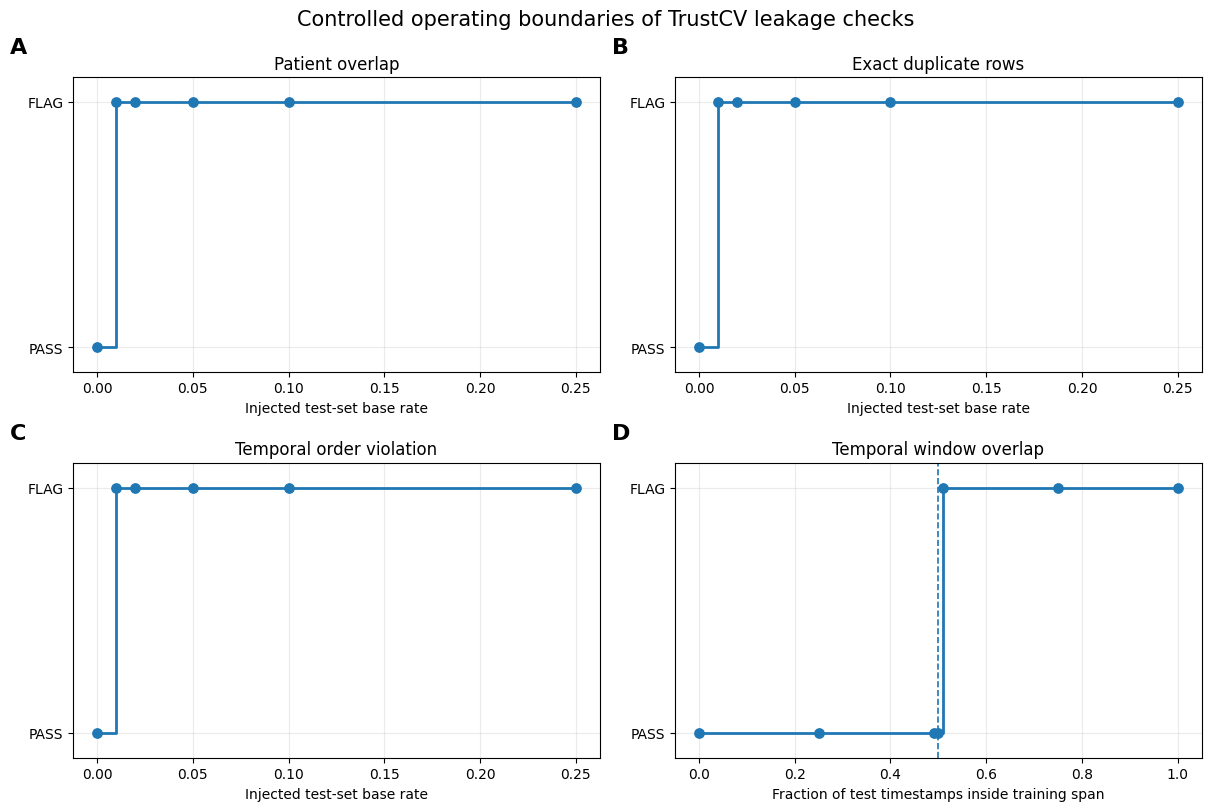

/content/trustcv_leakage_injection_outputs/Supplementary_Figure_S5_leakage_boundaries.png
/content/trustcv_leakage_injection_outputs/Supplementary_Figure_S5_leakage_boundaries.pdf


In [19]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)

panels = [
    (axes[0, 0], patient_results, "injected_test_base_rate", "flag", "A", "Patient overlap", "Injected test-set base rate"),
    (axes[0, 1], duplicate_results, "injected_test_base_rate", "flag", "B", "Exact duplicate rows", "Injected test-set base rate"),
    (axes[1, 0], temporal_order_results, "injected_test_base_rate", "flag", "C", "Temporal order violation", "Injected test-set base rate"),
    (axes[1, 1], temporal_overlap_results, "requested_overlap_fraction", "flag", "D", "Temporal window overlap", "Fraction of test timestamps inside training span"),
]

for ax, df, xcol, ycol, letter, title, xlabel in panels:
    y = df[ycol].astype(int)
    ax.step(df[xcol], y, where="post", linewidth=2)
    ax.scatter(df[xcol], y, s=45, zorder=3)
    ax.set_ylim(-0.1, 1.1)
    ax.set_yticks([0, 1], labels=["PASS", "FLAG"])
    ax.set_xlabel(xlabel)
    ax.set_title(title)
    ax.grid(True, axis="both", alpha=0.25)
    ax.text(-0.12, 1.08, letter, transform=ax.transAxes, fontsize=16, fontweight="bold")

axes[1, 1].axvline(0.50, linestyle="--", linewidth=1.2)
fig.suptitle("Controlled operating boundaries of TrustCV leakage checks", fontsize=15)

figure_png = OUTPUT_DIR / "Supplementary_Figure_S5_leakage_boundaries.png"
figure_pdf = OUTPUT_DIR / "Supplementary_Figure_S5_leakage_boundaries.pdf"
fig.savefig(figure_png, dpi=600, bbox_inches="tight")
fig.savefig(figure_pdf, bbox_inches="tight")
plt.show()
print(figure_png)
print(figure_pdf)

## 12. Save complete outputs and a run manifest

Please send back the generated ZIP file or, at minimum, the CSV tables, manifest, and displayed assertion summary. The source diff is also saved so the duplicate-check correction can be reviewed cleanly.

In [20]:
patient_results.to_csv(OUTPUT_DIR / "patient_overlap_sweep.csv", index=False)
duplicate_results.to_csv(OUTPUT_DIR / "exact_duplicate_sweep.csv", index=False)
temporal_order_results.to_csv(OUTPUT_DIR / "temporal_order_sweep.csv", index=False)
temporal_overlap_results.to_csv(OUTPUT_DIR / "temporal_overlap_sweep.csv", index=False)
control_results.to_csv(OUTPUT_DIR / "clean_controls_100_seeds.csv", index=False)
boundary_table.to_csv(OUTPUT_DIR / "Supplementary_Table_S20.csv", index=False)
boundary_table.to_latex(OUTPUT_DIR / "Supplementary_Table_S20.tex", index=False, escape=True)

# Save the patched method source for review.
method_source = inspect.getsource(DataLeakageChecker._check_duplicate_samples)
(OUTPUT_DIR / "patched_duplicate_method.py.txt").write_text(method_source, encoding="utf-8")

manifest = {
    "seed": SEED,
    "n_train": N_TRAIN,
    "n_test": N_TEST,
    "control_seed_count": len(list(CONTROL_SEEDS)),
    "repository_root": str(REPO_ROOT),
    "leakage_file": str(LEAKAGE_FILE),
    "duplicate_hash_index_excluded": "index=False" in method_source,
    "all_assertions_passed": True,
    "clean_control_flag_totals": control_summary["flag_count"].astype(int).to_dict(),
    "observed_boundaries": {
        "patient_first_flag_count": int(p_b["first_flag"]),
        "duplicate_first_flag_count": int(d_b["first_flag"]),
        "temporal_order_first_flag_count": int(t_b["first_flag"]),
        "temporal_overlap_last_pass": float(o_b["last_pass"]),
        "temporal_overlap_first_flag": float(o_b["first_flag"]),
    },
}
(OUTPUT_DIR / "run_manifest.json").write_text(json.dumps(manifest, indent=2), encoding="utf-8")

archive_path = shutil.make_archive(
    str(Path.cwd() / "trustcv_leakage_injection_outputs"),
    "zip",
    root_dir=OUTPUT_DIR,
)

print(json.dumps(manifest, indent=2))
print(f"\nOutput archive: {archive_path}")

{
  "seed": 42,
  "n_train": 200,
  "n_test": 100,
  "control_seed_count": 100,
  "repository_root": "/content/trustcv-main",
  "leakage_file": "/content/trustcv-main/trustcv/checkers/leakage.py",
  "duplicate_hash_index_excluded": true,
  "all_assertions_passed": true,
  "clean_control_flag_totals": {
    "patient_flag": 0,
    "duplicate_flag": 0,
    "temporal_flag": 0
  },
  "observed_boundaries": {
    "patient_first_flag_count": 1,
    "duplicate_first_flag_count": 1,
    "temporal_order_first_flag_count": 1,
    "temporal_overlap_last_pass": 0.5,
    "temporal_overlap_first_flag": 0.51
  }
}

Output archive: /content/trustcv_leakage_injection_outputs.zip
